# Experiment 4.0.1 — Binary vs multi-spike macro-LIF

Analysis-only notebook for the 2×2 hidden/output event-cap factorial. Training is performed by the Slurm array runner.

Primary question: does the one-event-per-250-ms communication cap explain a substantial part of the current SNN decoder gap?

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

repo = find_repo_root()
root = repo / 'notebooks' / 'artifacts' / 'experiment_4_0_1_multispike_macro_lif' / 'macro_lif_event_cap_factorial_v1'
eval_dir = root / 'evaluations'
n_eval = len(list(eval_dir.glob('*.json'))) if eval_dir.exists() else 0
required = [root / 'runs.csv', root / 'summary.csv', root / 'factorial_effects.csv', root / 'provenance.json']
ready = n_eval == 40 and all(path.exists() for path in required)
print(f'Artifact root: {root}')
print(f'Completed evaluations: {n_eval}/40')
print(f'Finalized outputs ready: {ready}')
if n_eval == 40 and not ready:
    print('Run: sbatch scripts/bash_script/SNN_Bash/finalize_exp_4_0_1_cpu.bash')


Artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_4_0_1_multispike_macro_lif/macro_lif_event_cap_factorial_v1
Completed evaluations: 40/40
Finalized outputs ready: True


In [2]:
if ready:
    summary = pd.read_csv(root / 'summary.csv')
    effects = pd.read_csv(root / 'factorial_effects.csv')
    runs = pd.read_csv(root / 'runs.csv')
    display(summary)
    display(effects)
    sanity_path = root / 'binary_sanity.csv'
    if sanity_path.exists():
        print('Custom cap=1 vs original Exp4.0 binary sanity check')
        display(pd.read_csv(sanity_path))
else:
    print('Skipping finalized tables until all 40 runs and finalizer outputs are present.')


,architecture,hidden_width,tau_mem_ms,variant,hidden_cap,output_cap,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,valid_count_macro_f1_mean,valid_count_macro_f1_std,...,hidden_fraction_gt1_mean,hidden_fraction_gt1_std,hidden_fraction_at_cap_mean,hidden_fraction_at_cap_std,output_mean_events_per_neuron_step_mean,output_mean_events_per_neuron_step_std,output_fraction_gt1_mean,output_fraction_gt1_std,output_fraction_at_cap_mean,output_fraction_at_cap_std
0,ff,128,2000.0,binary,1,1,0.292492,0.023936,0.275719,0.026375,...,0.000000,0.000000,0.274206,0.012150,0.148528,0.012193,0.000000,0.000000,0.148528,0.012193
1,ff,128,2000.0,multi_h,31,1,0.271697,0.028809,0.241402,0.026540,...,0.106934,0.006360,0.000000,0.000000,0.102582,0.017426,0.000000,0.000000,0.102582,0.017426
2,ff,128,2000.0,multi_ho,31,31,0.333834,0.013553,0.294446,0.018238,...,0.390375,0.020490,0.000000,0.000000,10.689360,0.564091,0.748333,0.017080,0.066595,0.010518
3,ff,128,2000.0,multi_o,1,31,0.285870,0.032326,0.218500,0.045972,...,0.000000,0.000000,0.428216,0.017727,6.245169,1.344307,0.779210,0.036909,0.000000,0.000000
4,rsnn,128,250.0,binary,1,1,0.354349,0.032936,0.334560,0.030613,...,0.000000,0.000000,0.288924,0.014687,0.142096,0.013479,0.000000,0.000000,0.142096,0.013479
5,rsnn,128,250.0,multi_h,31,1,0.245826,0.058430,0.206272,0.081671,...,0.178906,0.072697,0.003682,0.008180,0.046459,0.037300,0.000000,0.000000,0.046459,0.037300
6,rsnn,128,250.0,multi_ho,31,31,0.407640,0.025049,0.395307,0.023457,...,0.441217,0.019447,0.074129,0.029651,6.345517,0.453527,0.481695,0.042074,0.060234,0.012236
7,rsnn,128,250.0,multi_o,1,31,0.327240,0.032732,0.308788,0.037193,...,0.000000,0.000000,0.454203,0.011368,6.663583,0.464368,0.731376,0.024582,0.000772,0.001234


,architecture,seed,binary,multi_h,multi_o,multi_ho,hidden_effect_at_output1,output_effect_at_hidden1,hidden_effect_at_output31,output_effect_at_hidden31,interaction
0,ff,11,0.259872,0.264620,0.326552,0.327409,0.004748,0.066680,0.000857,0.062789,-0.003891
1,ff,23,0.283271,0.306073,0.239011,0.337490,0.022802,-0.044260,0.098479,0.031417,0.075676
2,ff,37,0.325233,0.248902,0.289710,0.313606,-0.076331,-0.035523,0.023896,0.064703,0.100226
3,ff,53,0.293212,0.241530,0.274559,0.347136,-0.051682,-0.018654,0.072577,0.105606,0.124259
4,ff,71,0.300871,0.297358,0.299519,0.343528,-0.003512,-0.001352,0.044009,0.046170,0.047522
5,rsnn,11,0.362208,0.327191,0.369922,0.385544,-0.035017,0.007714,0.015623,0.058353,0.050640
6,rsnn,23,0.372749,0.244186,0.311020,0.398669,-0.128562,-0.061729,0.087649,0.154482,0.216212
7,rsnn,37,0.310388,0.176215,0.290867,0.406031,-0.134173,-0.019521,0.115163,0.229815,0.249336
8,rsnn,53,0.393611,0.208086,0.311842,0.450479,-0.185525,-0.081769,0.138637,0.242393,0.324162
9,rsnn,71,0.332789,0.273452,0.352549,0.397476,-0.059336,0.019760,0.044927,0.124024,0.104264


Custom cap=1 vs original Exp4.0 binary sanity check


,architecture,hidden_width,tau_mem_ms,seed,original_exp4_0_binary_ba,custom_cap1_binary_ba,custom_minus_original
0,ff,128,2000.0,11,0.263268,0.259872,-0.003396
1,ff,128,2000.0,23,0.295897,0.283271,-0.012626
2,ff,128,2000.0,37,0.323375,0.325233,0.001858
3,ff,128,2000.0,53,0.295390,0.293212,-0.002178
4,ff,128,2000.0,71,0.344229,0.300871,-0.043359
5,rsnn,128,250.0,11,0.332723,0.362208,0.029485
6,rsnn,128,250.0,23,0.375653,0.372749,-0.002904
7,rsnn,128,250.0,37,0.277235,0.310388,0.033153
8,rsnn,128,250.0,53,0.368659,0.393611,0.024952
9,rsnn,128,250.0,71,0.392172,0.332789,-0.059384


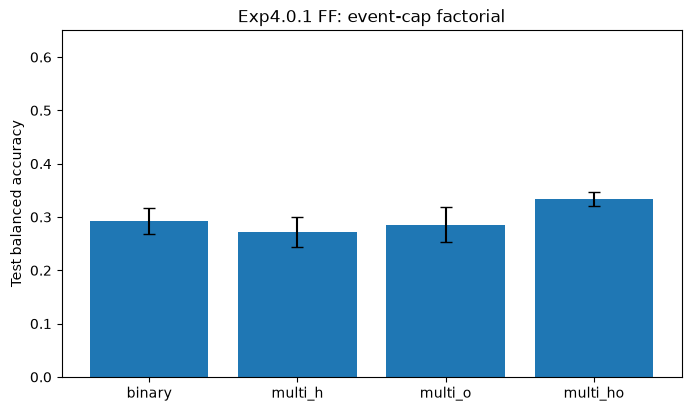

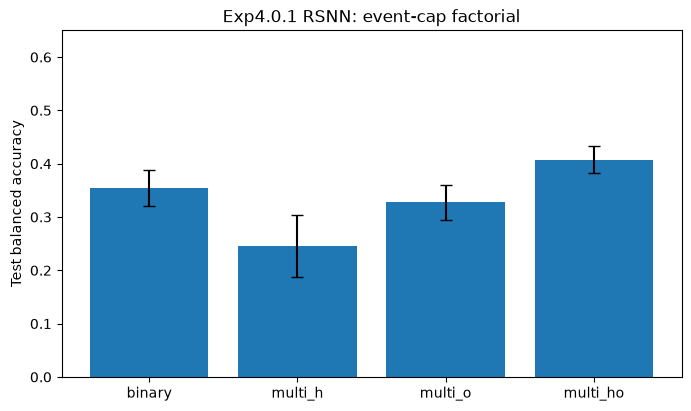

In [3]:
if ready:
    test = runs[runs['split'] == 'test'].copy()
    order = ['binary', 'multi_h', 'multi_o', 'multi_ho']
    plot_df = (test.groupby(['architecture', 'variant'])['valid_count_balanced_accuracy']
               .agg(['mean', 'std']).reset_index())
    for architecture in ['ff', 'rsnn']:
        sub = plot_df[plot_df['architecture'] == architecture].set_index('variant').reindex(order)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.bar(sub.index, sub['mean'], yerr=sub['std'], capsize=4)
        ax.set_ylabel('Test balanced accuracy')
        ax.set_title(f'Exp4.0.1 {architecture.upper()}: event-cap factorial')
        ax.set_ylim(0, max(0.65, float((sub['mean'] + sub['std'].fillna(0)).max()) + 0.05))
        plt.show()


,architecture,variant,hidden_fraction_gt1,hidden_fraction_at_cap,output_fraction_gt1,output_fraction_at_cap
0,ff,binary,0.000000,0.274206,0.000000,0.148528
1,ff,multi_h,0.106934,0.000000,0.000000,0.102582
2,ff,multi_ho,0.390375,0.000000,0.748333,0.066595
3,ff,multi_o,0.000000,0.428216,0.779210,0.000000
4,rsnn,binary,0.000000,0.288924,0.000000,0.142096
5,rsnn,multi_h,0.178906,0.003682,0.000000,0.046459
6,rsnn,multi_ho,0.441217,0.074129,0.481695,0.060234
7,rsnn,multi_o,0.000000,0.454203,0.731376,0.000772


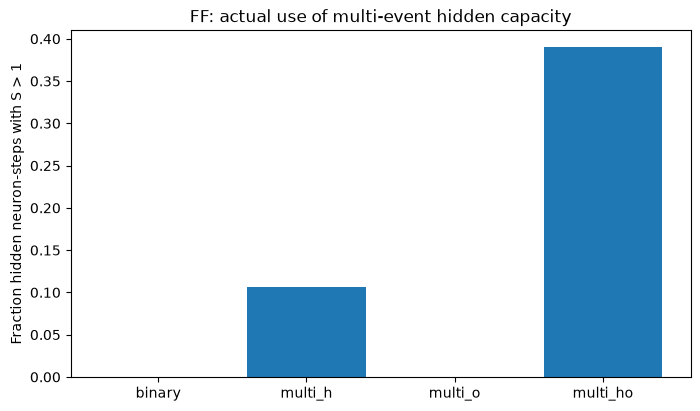

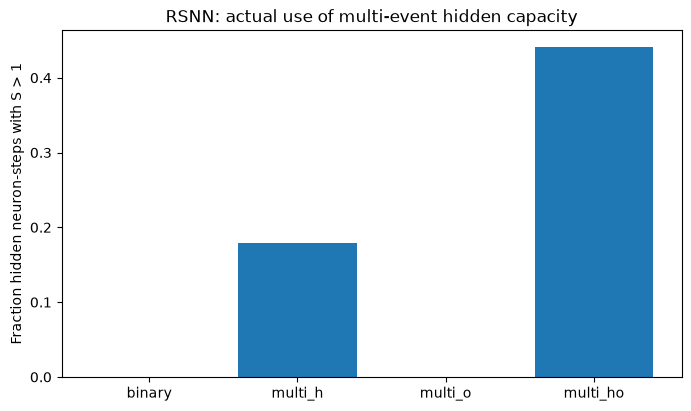

In [4]:
if ready:
    test = runs[runs['split'] == 'test'].copy()
    diag = (test.groupby(['architecture', 'variant'])
            [['hidden_fraction_gt1', 'hidden_fraction_at_cap', 'output_fraction_gt1', 'output_fraction_at_cap']]
            .mean().reset_index())
    display(diag)
    for architecture in ['ff', 'rsnn']:
        sub = diag[diag['architecture'] == architecture].set_index('variant').reindex(['binary', 'multi_h', 'multi_o', 'multi_ho'])
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.bar(sub.index, sub['hidden_fraction_gt1'])
        ax.set_ylabel('Fraction hidden neuron-steps with S > 1')
        ax.set_title(f'{architecture.upper()}: actual use of multi-event hidden capacity')
        plt.show()
